# Importando bibliotecas

In [ ]:
! pip install librosa

In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from google.colab import drive
import zipfile
import os
import IPython.display as ipd
import h5py
from joblib import Parallel, delayed
from tqdm import tqdm
import scipy.fftpack

# Carregando e salvando os dados

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%%time
zip_path = '/content/drive/MyDrive/PSI5123 - Aprendizagem de Máquina de Sinais de Áudio e Voz (2026)/Projeto/for-2sec.zip'
extract_path = '/content/dataset_local'

# Extração rápida
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extração concluída!")

Extração concluída!
CPU times: user 14 s, sys: 5.28 s, total: 19.3 s
Wall time: 40.2 s


In [4]:
def contar_arquivos(caminho_pasta):
    # Retorna a soma de 1 para cada item que for um arquivo válido
    return sum(1 for entrada in os.scandir(caminho_pasta) if entrada.is_file())

for major_folder in ['training','validation','testing']:
  for minor_folder in ['fake','real']:
    print(f'{major_folder} \t{minor_folder}:\t{contar_arquivos("/content/dataset_local/for-2seconds/"+major_folder+"/"+minor_folder)} files')

training 	fake:	6978 files
training 	real:	6978 files
validation 	fake:	1413 files
validation 	real:	1413 files
testing 	fake:	544 files
testing 	real:	544 files


In [5]:
def mapear_tipos_de_arquivos(caminho_pasta):
    extensoes = set()

    # os.walk varre a pasta principal e todas as subpastas automaticamente
    for raiz, _, arquivos in os.walk(caminho_pasta):
        for arquivo in arquivos:
            # os.path.splitext separa o nome do arquivo da extensão (ex: 'audio.wav' -> ('audio', '.wav'))
            _, ext = os.path.splitext(arquivo)

            # Se o arquivo não tiver extensão (ex: 'README'), categoriza como 'Sem Extensão'
            if ext == '':
                ext = 'Sem Extensão'
            else:
                ext = ext.lower() # Padroniza para minúsculo (.WAV -> .wav)

            extensoes = set.union(extensoes,set({ext}))
    return extensoes

mapear_tipos_de_arquivos('/content/dataset_local/for-2seconds/testing/fake')

{'.wav'}

# Procesando uma amostra

sr: 16000
(32000,)


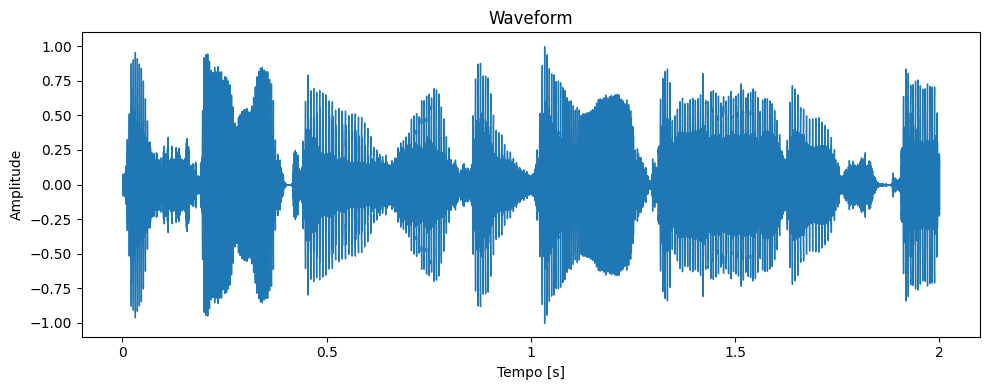

In [6]:
x, sr = librosa.load('/content/dataset_local/for-2seconds/testing/fake/file100.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav', sr = 16000)
print('sr:',sr)
print(x.shape)
display(ipd.Audio(x, rate = sr))
plt.figure(figsize=(10, 4))
librosa.display.waveshow(x,sr=sr)
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.title('Waveform')
plt.tight_layout()
plt.show()

sr: 16000
(32000,)


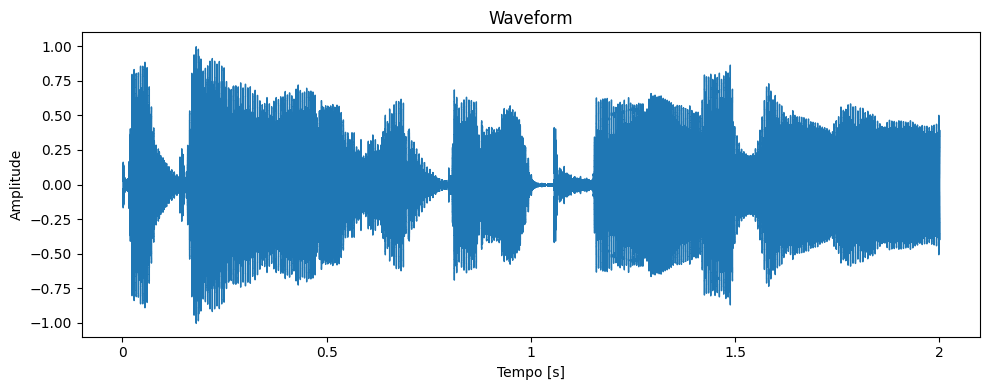

In [7]:
x, sr = librosa.load('/content/dataset_local/for-2seconds/testing/real/file2038.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav', sr = 16000)
print('sr:',sr)
print(x.shape)
display(ipd.Audio(x, rate = sr))
plt.figure(figsize=(10, 4))
librosa.display.waveshow(x,sr=sr)
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.title('Waveform')
plt.tight_layout()
plt.show()

# Features

## Function

In [8]:
file_path = '/content/dataset_local/for-2seconds/testing/real/file2038.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav'#'/content/dataset_local/for-2seconds/testing/fake/file100.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav'
audio, sr = librosa.load(file_path, sr=16000, duration=2.0)
stft = np.abs(librosa.stft(audio))
stft.shape

(1025, 63)

# Treinamento do modelo

# Salvando inputs

### Script de Extração e Pré-processamento

Este script lê os áudios, aplica normalização MinMax, injeta ruído (apenas no treino), extrai MFCC e LFCC, normaliza (Z-score) usando a base do treino e salva tudo em um arquivo .h5.

In [9]:
import os
import librosa
import numpy as np
import h5py
import scipy
from tqdm import tqdm

# --- CONFIGURAÇÕES ---
DATA_DIR = '/content/dataset_local/for-2seconds/' # Altere para o caminho principal
SR = 16000 # Taxa de amostragem padrão
DURATION = 2.0
N_COEFFS = 40
H5_FILE = '/content/drive/MyDrive/PSI5123 - Aprendizagem de Máquina de Sinais de Áudio e Voz (2026)/Projeto/dataset_treino.h5'
np.random.seed(123)

def minmax_normalize(audio):
    """Aplica normalização MinMax na amplitude do áudio para a escala [0, 1]"""
    min_val = np.min(audio)
    max_val = np.max(audio)
    if max_val - min_val > 0:
        return (audio - min_val) / (max_val - min_val)
    return audio

def add_white_noise(audio, noise_factor=0.005):
    """Adiciona ruído branco para Data Augmentation"""
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

def extract_features(audio, sr):
    """Extrai 40 MFCCs e 40 LFCCs e os concatena"""
    # 1. MFCC (Escala Mel)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_COEFFS)

    # 2. LFCC (Escala Linear) usando STFT -> Power to DB -> DCT
    # Usamos n_fft=512 (janelas padrão do librosa)
    stft = np.abs(librosa.stft(audio))
    stft_db = librosa.amplitude_to_db(stft, ref=np.max)
    # Aplicando DCT ao longo do eixo das frequências para pegar os cepstrais
    lfcc = scipy.fftpack.dct(stft_db, type=2, axis=0, norm='ortho')[:N_COEFFS]

    # Concatena no eixo das "features" (linhas). Resultado: shape (80, frames)
    combined = np.vstack((mfcc, lfcc))
    return combined

def process_split(split_name, is_train=False):
    features, labels = [], []
    for label_idx, label_name in enumerate(['fake', 'real']):
        folder_path = os.path.join(DATA_DIR, split_name, label_name)
        if not os.path.exists(folder_path): continue

        for file in tqdm(os.listdir(folder_path), desc=f"Processando {split_name}/{label_name}"):
            if not file.endswith('.wav'): continue

            filepath = os.path.join(folder_path, file)
            # Carrega exatamente 2 segundos
            audio, _ = librosa.load(filepath, sr=SR, duration=DURATION)

            # Passo 1: MinMax da amplitude
            audio = minmax_normalize(audio)

            # Passo 2: Ruído apenas no treino
            if is_train:
                audio = add_white_noise(audio)

            # Passo 3: Extração de Features
            feat = extract_features(audio, SR)

            # Ajuste de tamanho: padroniza a quantidade de frames (ex: 63 frames para 2s em 16kHz)
            max_len = 63
            if feat.shape[1] < max_len:
                feat = np.pad(feat, ((0,0), (0, max_len - feat.shape[1])), mode='constant')
            else:
                feat = feat[:, :max_len]

            features.append(feat)
            labels.append(label_idx)

    return np.array(features), np.array(labels)

# Processando os dados
X_train, y_train = process_split('training', is_train=True)
X_val, y_val = process_split('validation', is_train=False)
X_test, y_test = process_split('testing', is_train=False)
# =====================================================================
# Passo 4: Normalização Z-Score SEPARADA para MFCC e LFCC
# =====================================================================

# 1. Separar os blocos de treino para calcular as estatísticas isoladas
X_train_mfcc = X_train[:, :40, :]
X_train_lfcc = X_train[:, 40:, :]

# 2. Calcular Média e Desvio Padrão específicos para cada feature (com base APENAS no treino)
mean_train_mfcc = np.mean(X_train_mfcc, axis=(0, 2), keepdims=True)
std_train_mfcc = np.std(X_train_mfcc, axis=(0, 2), keepdims=True) + 1e-8

mean_train_lfcc = np.mean(X_train_lfcc, axis=(0, 2), keepdims=True)
std_train_lfcc = np.std(X_train_lfcc, axis=(0, 2), keepdims=True) + 1e-8

def normalize_features(X_split):
    """Função auxiliar para fatiar, aplicar o Z-Score correto e remontar o tensor"""
    # Fatia os blocos do split atual (seja treino, validação ou teste)
    mfcc_part = X_split[:, :40, :]
    lfcc_part = X_split[:, 40:, :]

    # Aplica a normalização usando estritamente os parâmetros gerados pelo treino
    mfcc_norm = (mfcc_part - mean_train_mfcc) / std_train_mfcc
    lfcc_norm = (lfcc_part - mean_train_lfcc) / std_train_lfcc

    # Concatena de volta no eixo 1 (linhas das features)
    return np.concatenate((mfcc_norm, lfcc_norm), axis=1)

# 3. Aplicar a normalização isolada em todos os conjuntos de dados
X_train = normalize_features(X_train)
X_val   = normalize_features(X_val)
X_test  = normalize_features(X_test)

print("[*] Z-Score aplicado com sucesso de forma independente para MFCC e LFCC!")

# # Passo 5: Salvar em .h5 com precisão float16
with h5py.File(H5_FILE, 'w') as hf:
    hf.create_dataset('X_train', data=X_train.astype(np.float16))
    hf.create_dataset('y_train', data=y_train.astype(np.int8))
    hf.create_dataset('X_val', data=X_val.astype(np.float16))
    hf.create_dataset('y_val', data=y_val.astype(np.int8))
    hf.create_dataset('X_test', data=X_test.astype(np.float16))
    hf.create_dataset('y_test', data=y_test.astype(np.int8))

print("Dataset salvo com sucesso em formato HDF5 (float16)!")

Processando testing/real: 100%|██████████| 544/544 [00:11<00:00, 45.91it/s]


[*] Z-Score aplicado com sucesso de forma independente para MFCC e LFCC!
Dataset salvo com sucesso em formato HDF5 (float16)!


# Rede Convolucional PyTorch (Leve e Rápida)

Para dados estruturados como (Canais, Tempo) — no nosso caso (40, 63) —, uma CNN 1D é muito mais leve e processa muito mais rápido que uma CNN 2D convencional.

In [10]:
H5_FILE = '/content/drive/MyDrive/PSI5123 - Aprendizagem de Máquina de Sinais de Áudio e Voz (2026)/Projeto/dataset_treino.h5'

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import h5py
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class AudioFeatureDataset(Dataset):
    def __init__(self, h5_file, split='train', feature_type='mfcc'):
        self.split = split
        self.feature_type = feature_type

        with h5py.File(h5_file, 'r') as hf:
            self.X = hf[f'X_{split}'][:]
            self.y = hf[f'y_{split}'][:]

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Fatiamento: Pega apenas os canais relevantes
        if self.feature_type == 'mfcc':
            x_feat = self.X[idx][:40, :] # Canais 0 a 39
        elif self.feature_type == 'lfcc':
            x_feat = self.X[idx][40:, :] # Canais 40 a 79

        x = torch.tensor(x_feat, dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y

class LightAudioCNN(nn.Module):
    def __init__(self):
        super(LightAudioCNN, self).__init__()
        # Reduzido de 32 para 16
        self.conv1 = nn.Conv1d(in_channels=40, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)

        # Reduzido de 64 para 16
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=16, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(0.2) # Leve redução no dropout já que a rede tem menos capacidade

        self.flatten = nn.Flatten()
        # O cálculo do tamanho pós-pooling continua resultando em tempo = 15.
        # 16 canais * 15 frames = 240 neurônios de entrada na FC.
        self.fc = nn.Linear(16 * 15, 2)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.dropout(self.pool(self.relu(self.conv2(x))))
        x = self.fc(self.flatten(x))
        return x

## Nova Função de Treinamento com Monitoramento de Validação

In [12]:
import matplotlib.pyplot as plt
import random
import numpy as np
import torch

def set_seed(seed=42):
    # Python built-in random module
    random.seed(seed)

    # Numpy library
    np.random.seed(seed)

    # PyTorch global seed (covers CPU and all GPUs)
    torch.manual_seed(seed)

    # Alternative explicit CUDA seed safety
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Force deterministic operations in CUDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Enforce deterministic PyTorch algorithms
    torch.use_deterministic_algorithms(True)

def train_model_with_validation(feature_name, epochs=60):
    set_seed(1234)

    print(f"\n{'='*40}\nTreinamento + Validação: {feature_name.upper()}\n{'='*40}")

    # 1. Preparar os Loaders (Treino e Validação)
    train_dataset = AudioFeatureDataset(H5_FILE, 'train', feature_name)
    val_dataset = AudioFeatureDataset(H5_FILE, 'val', feature_name) # Mudado para 'val'

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

    model = LightAudioCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    os.makedirs('checkpoints', exist_ok=True)

    # Listas para guardar o histórico de perda e plotar depois
    history = {
        'train_loss': [],
        'val_loss': []
    }

    best_val_loss = float('inf')
    best_epoch = 0

    for epoch in range(epochs):
        # --- FASE DE TREINO ---
        model.train()
        running_train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        epoch_train_loss = running_train_loss / len(train_loader)
        history['train_loss'].append(epoch_train_loss)

        # --- FASE DE VALIDAÇÃO ---
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                val_outputs = model(val_inputs)
                v_loss = criterion(val_outputs, val_labels)
                running_val_loss += v_loss.item()

        epoch_val_loss = running_val_loss / len(val_loader)
        history['val_loss'].append(epoch_val_loss)

        # --- SALVAR O MELHOR MODELO (Prevenção de Overfitting) ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_epoch = epoch + 1
            best_ckpt_path = f'checkpoints/model_{feature_name}_best.pth'
            torch.save(model.state_dict(), best_ckpt_path)

        # Print de progresso a cada 10 épocas
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Época {epoch+1:02d}/{epochs} | Treino Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    print(f"\n[*] Treinamento concluído! O melhor ponto de parada foi na Época {best_epoch} (Val Loss: {best_val_loss:.4f})")
    print(f"[*] Pesos ideais salvos em: 'checkpoints/model_{feature_name}_best.pth'")

    # Carrega os melhores pesos de volta no modelo antes de retornar
    model.load_state_dict(torch.load(f'checkpoints/model_{feature_name}_best.pth'))

    return model, history

def plot_loss_curves(history_mfcc, history_lfcc):
    epochs_range = range(1, len(history_mfcc['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Gráfico 1: MFCC
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history_mfcc['train_loss'], 'b-', label='Treino Loss')
    plt.plot(epochs_range, history_mfcc['val_loss'], 'r-', label='Validação Loss')
    plt.title('Curva de Perda (Loss) - MFCC')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Gráfico 2: LFCC
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history_lfcc['train_loss'], 'b-', label='Treino Loss')
    plt.plot(epochs_range, history_lfcc['val_loss'], 'r-', label='Validação Loss')
    plt.title('Curva de Perda (Loss) - LFCC')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


Treinamento + Validação: MFCC
Época 01/60 | Treino Loss: 0.3826 | Val Loss: 0.3986
Época 10/60 | Treino Loss: 0.0502 | Val Loss: 0.2376
Época 20/60 | Treino Loss: 0.0255 | Val Loss: 0.2744
Época 30/60 | Treino Loss: 0.0166 | Val Loss: 0.4898
Época 40/60 | Treino Loss: 0.0118 | Val Loss: 0.9876
Época 50/60 | Treino Loss: 0.0070 | Val Loss: 1.3957
Época 60/60 | Treino Loss: 0.0093 | Val Loss: 1.2202

[*] Treinamento concluído! O melhor ponto de parada foi na Época 15 (Val Loss: 0.1725)
[*] Pesos ideais salvos em: 'checkpoints/model_mfcc_best.pth'

Treinamento + Validação: LFCC
Época 01/60 | Treino Loss: 0.3712 | Val Loss: 0.1552
Época 10/60 | Treino Loss: 0.0463 | Val Loss: 0.0622
Época 20/60 | Treino Loss: 0.0239 | Val Loss: 0.0470
Época 30/60 | Treino Loss: 0.0142 | Val Loss: 0.0696
Época 40/60 | Treino Loss: 0.0081 | Val Loss: 0.0523
Época 50/60 | Treino Loss: 0.0084 | Val Loss: 0.0639
Época 60/60 | Treino Loss: 0.0088 | Val Loss: 0.0733

[*] Treinamento concluído! O melhor ponto de 

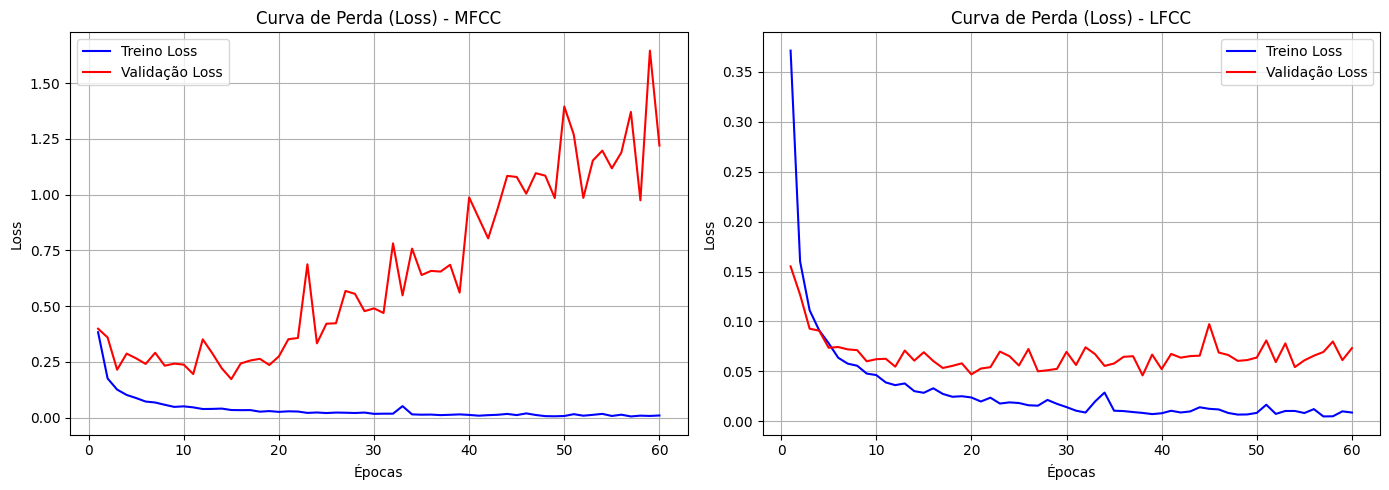

In [13]:
# Executa o treino coletando o modelo ideal e o histórico de perdas
model_mfcc, hist_mfcc = train_model_with_validation('mfcc', epochs=60)
model_lfcc, hist_lfcc = train_model_with_validation('lfcc', epochs=60)

# Gera a visualização para análise visual
plot_loss_curves(hist_mfcc, hist_lfcc)

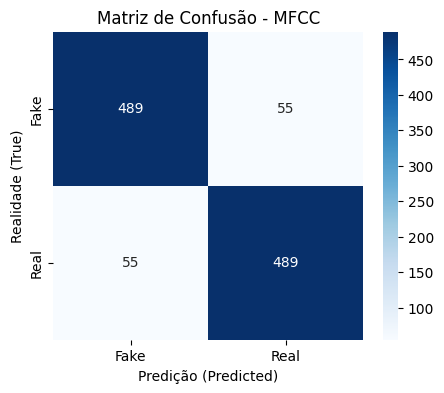

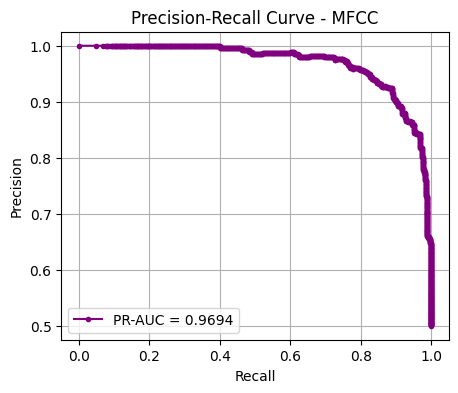

=== RESULTADOS FINAIS (MFCC) ===
Equal Error Rate (EER): 0.1011 (ou 10.11%)
Precision-Recall AUC:   0.9694
Best Threshold:         0.0013



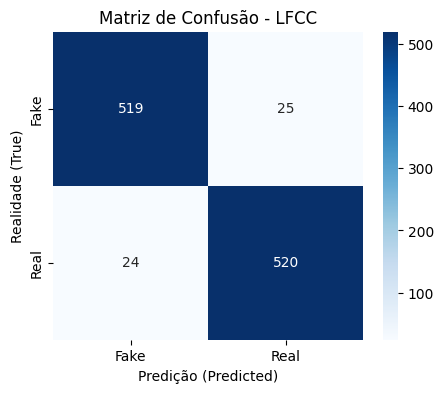

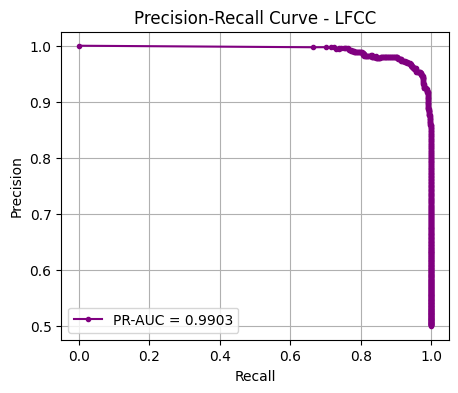

=== RESULTADOS FINAIS (LFCC) ===
Equal Error Rate (EER): 0.0460 (ou 4.60%)
Precision-Recall AUC:   0.9903
Best Threshold:         0.7031



In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, average_precision_score
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def evaluate_model(model, feature_name):
    test_loader = DataLoader(AudioFeatureDataset(H5_FILE, 'test', feature_name), batch_size=64, shuffle=False)

    model.eval()
    all_labels = []
    all_probs = [] # Probabilidades da classe positiva (ex: 'real' = 1)
    all_preds = [] # Predições binárias (0 ou 1)

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Aplica Softmax para obter probabilidades entre 0 e 1
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_labels.extend(labels.numpy())
            all_probs.extend(probs)
            all_preds.extend(preds)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)

    # --- 3. Cálculo do EER (Equal Error Rate) ---
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    fnr = 1 - tpr

    eer_index = np.nanargmin(np.absolute((fnr - fpr)))
    eer = fpr[eer_index]
    best_threshold = thresholds[eer_index]

    # --- 1. Matriz de Confusão ---
    cm = confusion_matrix(all_labels, all_probs >= best_threshold)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.title(f'Matriz de Confusão - {feature_name.upper()}')
    plt.ylabel('Realidade (True)')
    plt.xlabel('Predição (Predicted)')
    plt.show()

    # --- 2. Curva Precision-Recall + Cálculo da Área (PR-AUC) ---
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)

    # Duas formas equivalentes de calcular (usando average_precision_score por robustez)
    pr_auc = average_precision_score(all_labels, all_probs)

    plt.figure(figsize=(5, 4))
    # Adicionado o rótulo com a área calculada para aparecer na legenda
    plt.plot(recall, precision, marker='.', color='purple', label=f'PR-AUC = {pr_auc:.4f}')
    plt.title(f'Precision-Recall Curve - {feature_name.upper()}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='lower left') # Habilita a legenda no canto inferior esquerdo
    plt.grid(True)
    plt.show()

    print(f"=== RESULTADOS FINAIS ({feature_name.upper()}) ===")
    print(f"Equal Error Rate (EER): {eer:.4f} (ou {eer*100:.2f}%)")
    print(f"Precision-Recall AUC:   {pr_auc:.4f}")
    print(f"Best Threshold:         {best_threshold:.4f}")
    print("="*40 + "\n")

# Avaliando ambos os modelos compactos
evaluate_model(model_mfcc, 'mfcc')
evaluate_model(model_lfcc, 'lfcc')

# Visualização dos Inputs e Mapa de Saliência (Explicabilidade)

Para entender onde o modelo está "olhando", a técnica mais leve e direta no PyTorch é o Mapa de Saliência (Saliency Map) . Ele calcula o gradiente da classe prevista em relação à imagem (ou matriz de áudio, no nosso caso) de entrada. Basicamente, ele responde à pergunta: "Quais pixels (ou coeficientes) desta entrada, se fossem levemente alterados, causariam a maior mudança na decisão final do modelo?"

O código abaixo extrai um áudio do dataset de teste, plota o MFCC/LFCC original e, logo abaixo, plota o mapa de calor indicando onde a rede focou.

======= Real


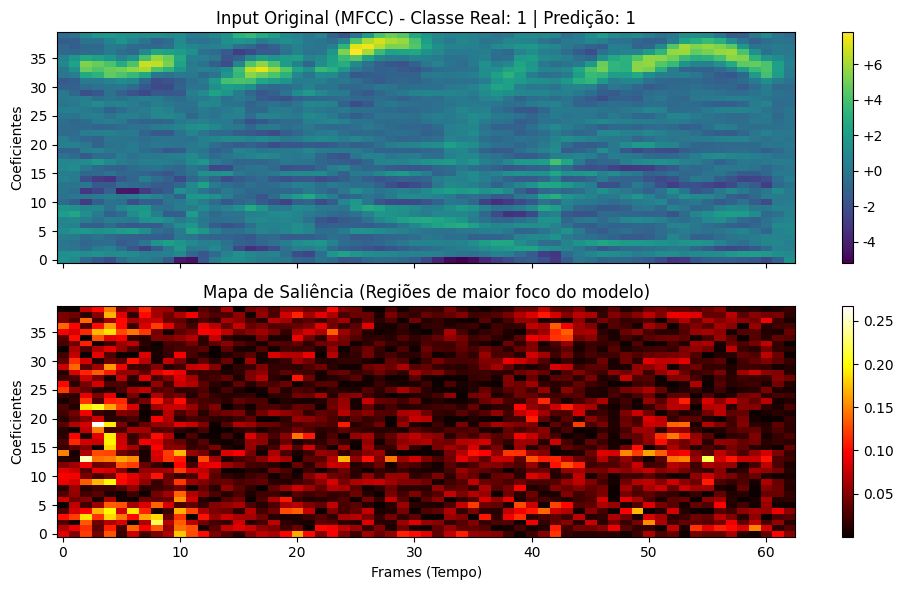

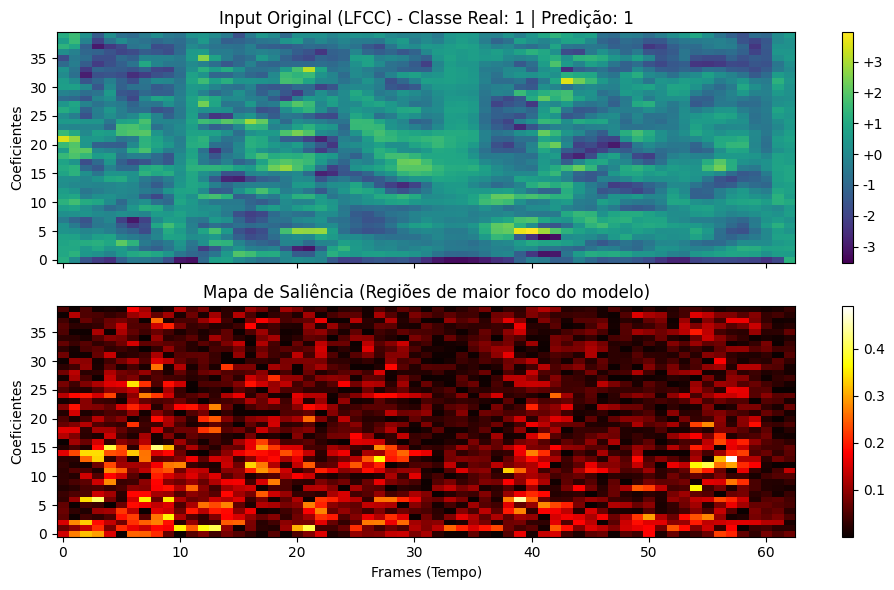

======= Fake


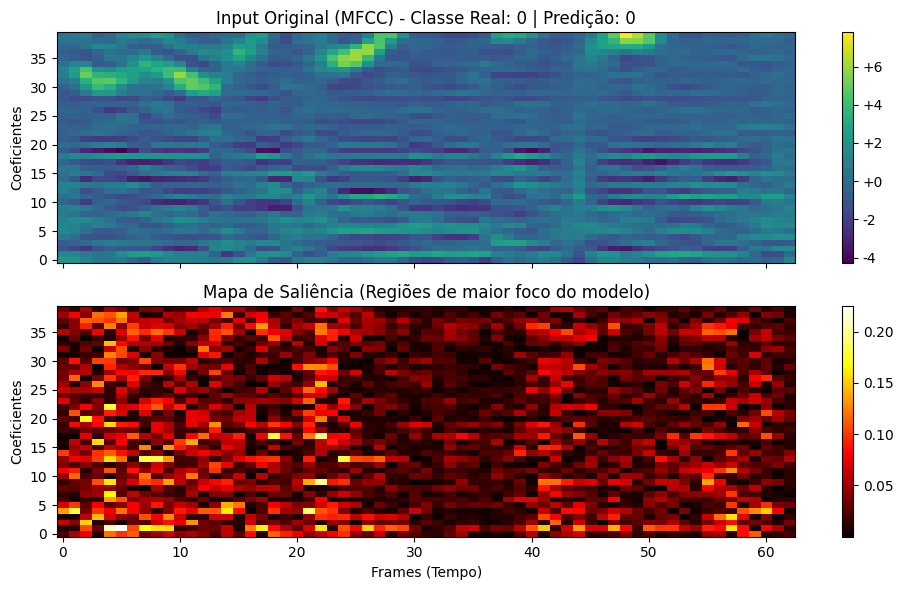

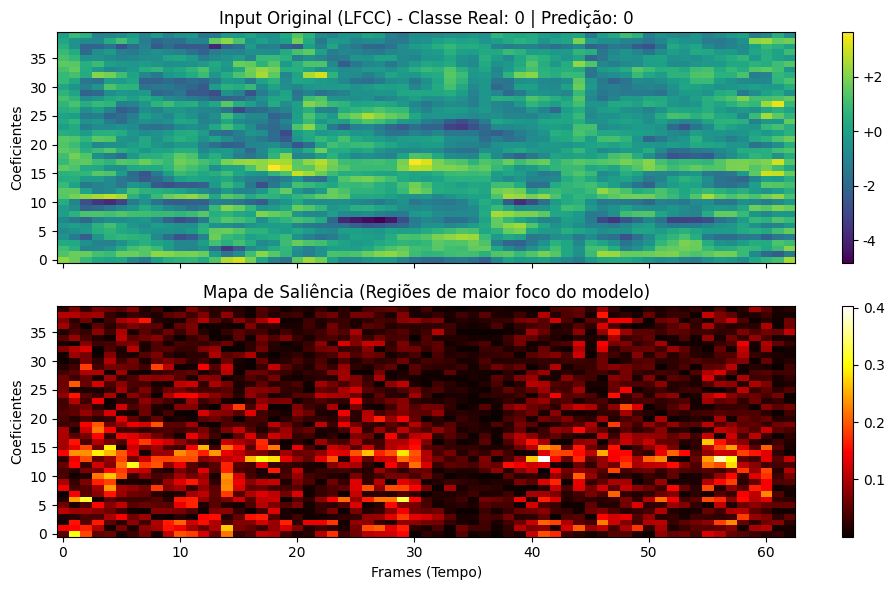

In [15]:
import matplotlib.pyplot as plt
import torch

def plot_input_and_saliency(model, dataset, index, feature_name):
    # Pega uma amostra do dataset
    input_tensor, label = dataset[index]

    # Prepara o tensor para o cálculo de gradientes
    input_tensor = input_tensor.unsqueeze(0).to(device) # Adiciona dimensão do Batch (1, 40, 63)
    input_tensor.requires_grad_()

    # Passa pelo modelo
    model.eval()
    outputs = model(input_tensor)

    # Pega o índice da classe com maior probabilidade
    _, predicted = torch.max(outputs.data, 1)

    # Força a rede a calcular os gradientes em relação a essa predição
    score = outputs[0][predicted[0]]
    score.backward()

    # CORREÇÃO AQUI: Removemos o torch.max para manter a matriz 2D (40, 63)
    # Pegamos o valor absoluto dos gradientes e removemos apenas a dimensão do Batch
    saliency = input_tensor.grad.data.abs().squeeze().cpu().numpy()

    # Array de entrada original
    input_data = input_tensor.squeeze().detach().cpu().numpy()

    # --- PLOTAGEM ---
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Plot 1: Input Original
    img1 = ax[0].imshow(input_data, aspect='auto', origin='lower', cmap='viridis')
    ax[0].set_title(f'Input Original ({feature_name.upper()}) - Classe Real: {label.item()} | Predição: {predicted.item()}')
    ax[0].set_ylabel('Coeficientes')
    fig.colorbar(img1, ax=ax[0], format='%+2.0f')

    # Plot 2: Mapa de Saliência
    img2 = ax[1].imshow(saliency, aspect='auto', origin='lower', cmap='hot')
    ax[1].set_title('Mapa de Saliência (Regiões de maior foco do modelo)')
    ax[1].set_ylabel('Coeficientes')
    ax[1].set_xlabel('Frames (Tempo)')
    fig.colorbar(img2, ax=ax[1])

    plt.tight_layout()
    plt.show()

# Usando as funções (assumindo que model_mfcc e model_lfcc já estão carregados na memória)
# Pegando o índice 5 do teste como exemplo
test_dataset_mfcc = AudioFeatureDataset(H5_FILE, split='test', feature_type='mfcc')
test_dataset_lfcc = AudioFeatureDataset(H5_FILE, split='test', feature_type='lfcc')

# Testando novamente
print('======= Real')
plot_input_and_saliency(model_mfcc, test_dataset_mfcc, index=555, feature_name='mfcc')
plot_input_and_saliency(model_lfcc, test_dataset_lfcc, index=555, feature_name='lfcc')
print('======= Fake')
plot_input_and_saliency(model_mfcc, test_dataset_mfcc, index=5, feature_name='mfcc')
plot_input_and_saliency(model_lfcc, test_dataset_lfcc, index=5, feature_name='lfcc')

# 3. Teste Estatístico (Teste de McNemar)

Como estamos testando dois modelos diferentes no exato mesmo dataset de teste (dados pareados) e a saída é categórica (acertou ou errou), o teste t-Student não é adequado. O padrão ouro estatístico para esse cenário em Machine Learning é o Teste de McNemar.Ele analisa uma tabela de contingência das discordâncias entre os modelos. A hipótese nula ($H_0$) é que os dois modelos têm a mesma taxa de erro. Se o $p\text{-value}$ for menor que 0.05, rejeitamos a hipótese nula e afirmamos que existe uma diferença estatisticamente significativa entre usar MFCC e LFCC.

In [16]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

def get_predictions_with_threshold(model, dataset, threshold=0.5):
    """Coleta predições aplicando um threshold customizado na classe positiva (Real)"""
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # 1. Pegamos a probabilidade da classe 1 (Real)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()

            # 2. Em vez de argmax, aplicamos o threshold customizado
            # Se for maior ou igual ao threshold vira 1 (Real), senão vira 0 (Fake)
            preds = (probs >= threshold).astype(int)

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

# ------------------------------------------------------------------
# CHAMADA DO TESTE: Usando os limiares ideais encontrados no passo anterior
# ------------------------------------------------------------------
# Substitua 'best_threshold_mfcc' e 'best_threshold_lfcc' pelas variáveis correspondentes
best_threshold_mfcc = 0.0010
best_threshold_lfcc = 0.9691

preds_mfcc, labels_true = get_predictions_with_threshold(model_mfcc, test_dataset_mfcc, threshold=best_threshold_mfcc)
preds_lfcc, _           = get_predictions_with_threshold(model_lfcc, test_dataset_lfcc, threshold=best_threshold_lfcc)


# 2. Criar booleanos de acertos e erros
correct_mfcc = (preds_mfcc == labels_true)
correct_lfcc = (preds_lfcc == labels_true)

# 3. Montar a Tabela de Contingência
# a: Ambos acertaram
# b: MFCC acertou, LFCC errou
# c: MFCC errou, LFCC acertou
# d: Ambos erraram
a = np.sum(correct_mfcc & correct_lfcc)
b = np.sum(correct_mfcc & ~correct_lfcc)
c = np.sum(~correct_mfcc & correct_lfcc)
d = np.sum(~correct_mfcc & ~correct_lfcc)

contingency_table = [[a, b],
                     [c, d]]

print("Tabela de Contingência (Acertos e Erros):")
print(f"Ambos Acertaram: {a} | MFCC Acertou, LFCC Errou: {b}")
print(f"MFCC Errou, LFCC Acertou: {c} | Ambos Erraram: {d}")
print("-" * 30)

# 4. Executar o Teste de McNemar
# Usamos exact=False para aproximação do Qui-Quadrado, o que inclui a correção de continuidade de Edwards.
resultado_mcnemar = mcnemar(contingency_table, exact=False, correction=False)

print(f"Estatística de McNemar: {resultado_mcnemar.statistic:.4f}")
print(f"P-value: {resultado_mcnemar.pvalue:.4e}")
print("-" * 30)

# ... (código anterior do Teste de McNemar) ...

print("\n" + "="*40)
print("VEREDITO FINAL DO TESTE ESTATÍSTICO")
print("="*40)

alpha = 0.05

if resultado_mcnemar.pvalue >= alpha:
    print("Veredito: EMPATE TÉCNICO.")
    print("Justificativa: Como o p-value é >= 0.05, a diferença de acertos e erros entre os modelos não é estatisticamente significativa.")
else:
    # Se p < 0.05, a diferença é real. Agora olhamos quem ganhou os pontos exclusivos.
    if b > c:
        print("Veredito: MFCC VENCEU!")
        print(f"Justificativa: O modelo MFCC acertou {b} casos que o LFCC errou.")
        print(f"Em contrapartida, o LFCC só conseguiu acertar {c} casos onde o MFCC falhou.")
        print("Portanto, o modelo baseado em características Mel-Cepstrais (MFCC) errou significativamente menos neste dataset.")

    elif c > b:
        print("Veredito: LFCC VENCEU!")
        print(f"Justificativa: O modelo LFCC acertou {c} casos que o MFCC errou.")
        print(f"Em contrapartida, o MFCC só conseguiu acertar {b} casos onde o LFCC falhou.")
        print("Portanto, o modelo baseado em características Lineares (LFCC) errou significativamente menos neste dataset.")

    else:
        # Caso raríssimo onde p < 0.05 mas b == c (a estatística de correção de Edwards pode causar isso dependendo do tamanho de 'a' e 'd')
        print("Veredito: INCONCLUSIVO.")
        print("Justificativa: Embora haja relevância estatística, os acertos exclusivos são idênticos.")

Tabela de Contingência (Acertos e Erros):
Ambos Acertaram: 950 | MFCC Acertou, LFCC Errou: 30
MFCC Errou, LFCC Acertou: 88 | Ambos Erraram: 20
------------------------------
Estatística de McNemar: 28.5085
P-value: 9.3289e-08
------------------------------

VEREDITO FINAL DO TESTE ESTATÍSTICO
Veredito: LFCC VENCEU!
Justificativa: O modelo LFCC acertou 88 casos que o MFCC errou.
Em contrapartida, o MFCC só conseguiu acertar 30 casos onde o LFCC falhou.
Portanto, o modelo baseado em características Lineares (LFCC) errou significativamente menos neste dataset.


In [17]:
import IPython
from IPython.display import Image, display
import base64

# Código Mermaid atualizado para a versão compacta (16 canais)
mermaid_graph = """
graph LR
    %% Estilos
    classDef input fill:#2b2b2b,stroke:#fff,stroke-width:2px,color:#fff;
    classDef layer fill:#1f4e79,stroke:#fff,stroke-width:1px,color:#fff;
    classDef activation fill:#d9534f,stroke:#fff,stroke-width:1px,color:#fff;
    classDef pool fill:#f0ad4e,stroke:#fff,stroke-width:1px,color:#fff;
    classDef regularize fill:#5bc0de,stroke:#fff,stroke-width:1px,color:#fff;
    classDef flatten fill:#5cb85c,stroke:#fff,stroke-width:1px,color:#fff;
    classDef output fill:#222,stroke:#5cb85c,stroke-width:2px,color:#fff;

    %% Fluxo
    In["Entrada: Coeficientes de Áudio <br><b>Shape: (B, 40, 63)</b>"]:::input

    C1["nn.Conv1d <br>in: 40 | out: 16<br>Kernel: 3, Pad: 1"]:::layer
    R1["nn.ReLU"]:::activation
    P1["nn.MaxPool1d <br>Kernel: 2, Stride: 2"]:::pool

    C2["nn.Conv1d <br>in: 16 | out: 16<br>Kernel: 3, Pad: 1"]:::layer
    R2["nn.ReLU"]:::activation
    P2["nn.MaxPool1d <br>Kernel: 2, Stride: 2"]:::pool
    D2["nn.Dropout <br>p: 0.2"]:::regularize

    Flat["nn.Flatten"]:::flatten
    FC["nn.Linear <br>in: 240 | out: 2"]:::layer
    Out["Saída: Logits <br><b>Shape: (B, 2)</b>"]:::output

    %% Conexões e Evolução dos Shapes (Esquerda para a Direita)
    In --> |"B, 40, 63"| C1
    C1 --> |"B, 16, 63"| R1
    R1 --> |"B, 16, 63"| P1
    P1 --> |"B, 16, 31"| C2
    C2 --> |"B, 16, 31"| R2
    R2 --> |"B, 16, 31"| P2
    P2 --> |"B, 16, 15"| D2
    D2 --> |"B, 16, 15"| Flat
    Flat --> |"B, 240"| FC
    FC --> Out
"""

# Renderização segura via API do mermaid.ink
graphbytes = mermaid_graph.encode("utf-8")
base64_bytes = base64.b64encode(graphbytes)
base64_string = base64_bytes.decode("ascii")
display(Image(url="https://mermaid.ink/img/" + base64_string))

Para entender profundamente a `LightAudioCNN`, imagine que o modelo funciona como um detetive que examina uma imagem digitalizada de um áudio. A rede começa olhando para os detalhes microscópicos da frequência (bordas, texturas temporais) e, camada por camada, vai resumindo essa informação até tomar uma decisão lógica de alto nível: **"Real" ou "Fake"**.

Vamos abrir o capô da rede e analisar a anatomia matemática e funcional de cada componente do seu diagrama:

---

## 1. Entrada: `In (B, 40, 63)`

* **O que faz:** É a porta de entrada dos seus dados pré-processados.
* **Como funciona:** O tensor possui três dimensões cruciais:
* $B$ (**Batch Size**): Quantos áudios estão sendo processados simultaneamente (ex: 64 áudios por vez).
* $40$ (**Canais / Características**): São os 40 coeficientes (MFCC ou LFCC). Eles atuam exatamente como as cores (RGB) em uma imagem tradicional, mas aqui representam diferentes faixas de frequência do áudio.
* $63$ (**Frames / Tempo**): O áudio original foi fatiado em 63 pequenos blocos de tempo ao longo do eixo horizontal.



---

## 2. Primeira Camada Convolucional: `C1 (nn.Conv1d)`

* **O que faz:** Extrai características locais básicas (combinações de frequências próximas que ocorrem em janelas de tempo curtas).
* **Como funciona:** A rede desliza 32 filtros (*kernels*) diferentes ao longo do eixo do tempo (horizontal). Cada filtro tem um tamanho de 3 frames (`kernel_size=3`).
* **Padding = 1:** Adiciona uma borda artificial de zeros nas extremidades do áudio para que o filtro consiga examinar o primeiríssimo e o primeiríssimo-último frame sem reduzir o tamanho do sinal. Por isso, o tempo se mantém em 63.
* **Mudança de Shape:** Passa de 40 para 32 canais porque agora não estamos olhando apenas para as frequências brutas, mas sim para **32 novos padrões abstratos** detectados.



---

## 3. Função de Ativação: `R1 (nn.ReLU)`

* **O que faz:** Introduz não-linearidade no sistema. Sem ela, a sua rede neural seria apenas uma enorme equação linear de primeiro grau incapaz de aprender padrões complexos de deepfakes.
* **Como funciona:** A operação matemática é extremamente simples: $f(x) = \max(0, x)$. Qualquer valor de saída da convolução que seja negativo vira exatamente `0.0`. Valores positivos passam inalterados.
* **Mudança de Shape:** Nenhuma. O formato continua `(B, 32, 63)`.

---

## 4. Redução de Resolução: `P1 (nn.MaxPool1d)`

* **O que faz:** Compacta a informação temporal, retendo apenas o que é mais importante e tornando a rede imune a pequenas variações de tempo (invariância temporal).
* **Como funciona:** Ela varre o eixo do tempo em blocos de 2 frames (`kernel_size=2`) dando passos de 2 em 2 (`stride=2`). De cada dupla de frames, ela descarta o menor valor e **mantém apenas o maior (o pico de energia)**.
* **Mudança de Shape:** O tempo é cortado pela metade de forma matemática truncada: $\lfloor 63 / 2 \rfloor = 31$. O formato vira `(B, 32, 31)`.

---

## 5. Segunda Camada Convolucional: `C2 (nn.Conv1d)`

* **O que faz:** Combina as características básicas extraídas pela `C1` para formar conceitos muito mais complexos e profundos (estruturas de áudio de nível superior).
* **Como funciona:** Semelhante à primeira, mas agora ela recebe os 32 canais intermediários e gera **64 novos filtros**. Ela cruza informações que estavam ligeiramente distantes no tempo original, mas que ficaram mais próximas após o primeiro pooling.
* **Mudança de Shape:** Eleva os canais para 64 e mantém o tempo em 31 graças ao preenchimento de borda (`pad=1`). Formato: `(B, 64, 31)`.

---

## 6. Ativação e Segundo Pooling: `R2` e `P2`

* **O que fazem:** Repetem o processo de filtragem não-linear e compactação de dados.
* **Como funciona:** O `R2` zera as ativações negativas e o `P2` divide novamente o tempo pela metade.
* **Mudança de Shape:** A operação de divisão de piso matemático atua sobre os 31 frames: $\lfloor 31 / 2 \rfloor = 15$. O formato resultante na saída de `P2` é `(B, 64, 15)`.

---

## 7. Regularização: `D2 (nn.Dropout)`

* **O que faz:** É a principal barreira da rede contra o **overfitting** (decorreba do dataset de treino).
* **Como funciona:** Durante o treinamento, a cada iteração, este bloco desativa ("desliga") aleatoriamente 30% (`p=0.3`) dos neurônios dessa camada, forçando a rede a não depender de um único caminho ou neurônio específico para classificar o áudio. Isso obriga a rede a aprender múltiplos caminhos robustos. *(Nota: no modo de teste/avaliação, o Dropout é desligado automaticamente pelo PyTorch).*
* **Mudança de Shape:** Nenhuma. O formato continua `(B, 64, 15)`.

---

## 8. Achatamento: `Flat (nn.Flatten)`

* **O que faz:** Transforma uma matriz bidimensional de características em um vetor unidimensional longo para que as camadas totalmente conectadas tradicionais consigam lê-lo.
* **Como funciona:** Ele pega os 64 canais e "estica" os seus 15 frames sequencialmente em uma única linha de dados.
* **Mudança de Shape:** Multiplicação direta: $64 \times 15 = 960$. O tensor deixa de ser uma matriz 2D e vira um vetor de formato `(B, 960)`.

---

## 9. Camada Totalmente Conectada / Classificadora: `FC (nn.Linear)`

* **O que faz:** Realiza a classificação final com base em todas as características abstratas acumuladas até aqui.
* **Como funciona:** Cada um dos 960 pontos do vetor de entrada se conecta a **2 neurônios de saída**. Essa camada pondera a importância de cada característica usando pesos aprendidos no treino para decidir qual classe acumula mais pontos.
* **Mudança de Shape:** Transforma o vetor de 960 posições em uma saída compacta de formato `(B, 2)`.

---

## 10. Saída: `Out` (Logits)

* **O que faz:** Entrega as pontuações brutas da predição para as duas classes possíveis.
* **Como funciona:** O modelo retorna dois números reais sem limite de escala: `[Nota para Fake, Nota para Real]`.
* Se a saída for `[5.4, -2.1]`, o modelo está muito confiante de que o áudio é **Fake** (Classe 0).
* Se a saída for `[-3.0, 4.2]`, o modelo indica forte certeza de que o áudio é **Real** (Classe 1).

Para entender o **Kernel** nas camadas 1D, o segredo é esquecer imagens bidimensionais (fotos) e focar em uma **linha do tempo**. No processamento de áudio, o Kernel se move em apenas uma direção: da esquerda para a direita (passado para o futuro).

Aqui está o funcionamento detalhado de cada um, com exemplos práticos.

---

## 1. O Kernel no `MaxPool1d` (Filtro de Seleção)

O Kernel do Max Pooling não possui pesos matemáticos que mudam com o treino. Ele funciona puramente como uma **janela deslizante de observação**. O papel dele é reduzir o tamanho do dado, atuando como um "resumidor" que retém apenas o pico de energia (o valor máximo).

### Exemplo Prático:

Imagine que temos a saída de uma convolução para um único canal de áudio ao longo de 6 frames temporais.
O nosso vetor de entrada é: `[2, 5, 1, 8, 3, 4]`

Configuração da sua rede: `nn.MaxPool1d(kernel_size=2, stride=2)`

* **`kernel_size=2`**: A janela olha para 2 números por vez.
* **`stride=2`**: A janela dá passos de 2 em 2 posições (sem sobreposição).

**O processo passo a passo:**

1. **Passo 1:** A janela se posiciona nos dois primeiros números: `[2, 5]`.
* *Operação:* Qual é o máximo entre 2 e 5? **5**.


2. **Passo 2:** O *stride=2* pula a janela duas posições para a frente: `[1, 8]`.
* *Operação:* Qual é o máximo entre 1 e 8? **8**.


3. **Passo 3:** A janela pula mais duas posições para a frente: `[3, 4]`.
* *Operação:* Qual é o máximo entre 3 e 4? **4**.



**Resultado Final:** O vetor que tinha tamanho 6 foi compactado para `[5, 8, 4]` (tamanho 3).
Se o seu sinal original de áudio tivesse um estalo ou ruído marcante de deepfake, o Max Pooling garante que essa característica forte sobreviva para a próxima camada.

---

## 2. O Kernel no `Conv1d` (Filtro de Aprendizado)

Diferente do pooling, o Kernel da Convolução possui **pesos matemáticos** (números decimais) que o modelo vai alterando a cada época de treino para aprender a detectar fraudes.

Na sua rede, a primeira camada é: `nn.Conv1d(in_channels=40, out_channels=32, kernel_size=3)`
Isso significa que cada um dos 32 filtros possui um Kernel de tamanho 3.

### Como ele varre o áudio:

O Kernel de tamanho 3 é uma matriz que captura 3 frames consecutivos de tempo, mas ele precisa abraçar **todos os canais de entrada ao mesmo tempo**.

* Como sua entrada tem 40 canais (coeficientes MFCC/LFCC), o Kernel real de um único filtro tem o formato tridimensional de `(40, 3)`.
* Ele senta em cima dos 3 primeiros frames de tempo cobrindo todas as 40 frequências.
* Ele multiplica cada peso do kernel pelo valor correspondente do áudio e **soma tudo**, gerando **um único número** de saída.
* Em seguida, ele dá um passo para o lado (`stride=1`) e repete a multiplicação para os frames 2, 3 e 4.

### O que o Kernel do Conv1d está procurando?

Como ele olha 3 frames adjacentes, ele está tentando capturar a **dinâmica de transição do áudio**.

* **Em áudios reais:** A transição de frequências humanas segue um padrão suave imposto pelas cordas vocais e pela boca. O Kernel aprende pesos que geram scores altos para essas transições naturais.
* **Em deepfakes:** Freqüentemente existem descontinuidades brutas ou artefatos matemáticos entre um frame e outro (pequenos estalos imperceptíveis ao ouvido humano). O Kernel convolucional aprende a "bater o olho" nessa quebra de padrão temporal e ativa um sinal de alerta que será enviado para o resto da rede.

Para entender a convolução 1D (`Conv1d`) na prática, vamos montar um exemplo numérico simples.

Imagine que estamos processando um áudio que possui apenas **2 canais de frequências** (em vez dos 40) e que dura apenas **4 frames de tempo**.

---

### 1. Os Dados de Entrada (O Áudio)

Nosso áudio é representado por essa matriz, onde cada coluna é um instante no tempo:

* **Canal 0 (Grave):** `[1, 2, 0, 3]`
* **Canal 1 (Agudo):** `[0, 1, 3, 1]`

### 2. O Filtro do Modelo (O Kernel)

O neurônio da nossa camada convolucional possui um detector (Kernel) de tamanho 2 (`kernel_size=2`). Para conseguir olhar os dois canais de áudio ao mesmo tempo, esse Kernel precisa ter pesos matemáticos para ambos os canais:

* **Pesos para o Canal 0:** `[2, 1]`
* **Pesos para o Canal 1:** `[0, 3]`

---

### 3. A Operação Matemática (Deslizando no Tempo)

A convolução vai deslizar esse bloco de pesos ao longo do tempo, multiplicando os valores e somando tudo no final. Como não estamos usando *padding*, o filtro vai dar **3 passos** da esquerda para a direita.

#### **Passo 1: Focando nos Frames 1 e 2**

O Kernel se posiciona no início do áudio:

* No Canal 0, ele abraça os valores `[1, 2]` e multiplica por seus pesos `[2, 1]`.
* No Canal 1, ele abraça os valores `[0, 1]` e multiplica por seus pesos `[0, 3]`.

$$\text{Cálculo} = (1 \times 2) + (2 \times 1) + (0 \times 0) + (1 \times 3)$$

$$\text{Cálculo} = 2 + 2 + 0 + 3 = \mathbf{7}$$

O primeiro número da nossa saída é **7**.

---

#### **Passo 2: Deslizando para os Frames 2 e 3**

O Kernel dá um passo para a direita (`stride=1`):

* No Canal 0, ele agora abraça `[2, 0]` e multiplica por `[2, 1]`.
* No Canal 1, ele agora abraça `[1, 3]` e multiplica por `[0, 3]`.

$$\text{Cálculo} = (2 \times 2) + (0 \times 1) + (1 \times 0) + (3 \times 3)$$

$$\text{Cálculo} = 4 + 0 + 0 + 9 = \mathbf{13}$$

O segundo número da nossa saída é **13**.

---

#### **Passo 3: Deslizando para os Frames 3 e 4**

O Kernel dá o seu último passo:

* No Canal 0, ele abraça `[0, 3]` e multiplica por `[2, 1]`.
* No Canal 1, ele abraça `[3, 1]` e multiplica por `[0, 3]`.

$$\text{Cálculo} = (0 \times 2) + (3 \times 1) + (3 \times 0) + (1 \times 3)$$

$$\text{Cálculo} = 0 + 3 + 0 + 3 = \mathbf{6}$$

O terceiro e último número da nossa saída é **6**.

---

### Resumo do Resultado

A nossa saída para esse filtro específico será um vetor unidimensional de tamanho 3: **`[7, 13, 6]`**.

Se a sua camada real tem `out_channels=32`, significa que o PyTorch possui **32 conjuntos de filtros independentes** como este do exemplo (cada um com seus próprios pesos aleatórios). Cada um deles vai gerar uma linha de características temporais diferente, resultando em uma matriz de saída com 32 canais.

In [ ]:
def analisar_parametros(model):
    # 1. Total absoluto de parâmetros (pesos + vieses)
    total_params = sum(p.numel() for p in model.parameters())

    # 2. Parâmetros treináveis (aqueles que o otimizador atualiza com gradiente)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # 3. Parâmetros não-zerados (pesos ativos na rede)
    non_zero_params = sum((p != 0).sum().item() for p in model.parameters())

    # 4. Parâmetros exatamente iguais a zero
    zero_params = total_params - non_zero_params

    # Porcentagens para o relatório
    pct_ativos = (non_zero_params / total_params) * 100
    pct_zerados = (zero_params / total_params) * 100

    # Exibição dos resultados
    print(f"========================================")
    print(f"   ANÁLISE DE PARÂMETROS: {model.__class__.__name__}")
    print(f"========================================")
    print(f"Total de Parâmetros:        {total_params:,}")
    print(f"Parâmetros Treináveis:      {trainable_params:,}")
    print("-" * 40)
    print(f"Parâmetros Válidos (Ativos): {non_zero_params:,} ({pct_ativos:.2f}%)")
    print(f"Parâmetros Zerados:         {zero_params:,} ({pct_zerados:.2f}%)")
    print(f"========================================")

# Executando para os seus modelos:
print("Análise do Modelo MFCC:")
analisar_parametros(model_mfcc)

print("\nAnálise do Modelo LFCC:")
analisar_parametros(model_lfcc)

Análise do Modelo MFCC:
   ANÁLISE DE PARÂMETROS: LightAudioCNN
Total de Parâmetros:        3,202
Parâmetros Treináveis:      3,202
----------------------------------------
Parâmetros Válidos (Ativos): 3,202 (100.00%)
Parâmetros Zerados:         0 (0.00%)

Análise do Modelo LFCC:
   ANÁLISE DE PARÂMETROS: LightAudioCNN
Total de Parâmetros:        3,202
Parâmetros Treináveis:      3,202
----------------------------------------
Parâmetros Válidos (Ativos): 3,202 (100.00%)
Parâmetros Zerados:         0 (0.00%)
